## Imports and display setup
Load analysis libraries and configure pandas column display plus seaborn plotting style.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
# Helper to load processed CSV with explicit dtypes to avoid mixed-type warnings
processed_dtypes = {
    "Store": "int64",
    "DayOfWeek": "int64",
    "Sales": "int64",
    "Customers": "int64",
    "Open": "int64",
    "Promo": "int64",
    "SchoolHoliday": "int64",
    "Promo2": "int64",
    "Year": "int64",
    "Month": "int64",
    "Week": "int64",
    "Day": "int64",
    "CompetitionDistance": "float64",
    "CompetitionOpenSinceYear": "Int64",
    "CompetitionOpenSinceMonth": "Int64",
    "Promo2SinceYear": "Int64",
    "Promo2SinceWeek": "Int64",
    "StoreType": "category",
    "Assortment": "category",
    "StateHoliday": "category",
    "PromoInterval": "category",
}

def load_processed(path: str = "../data/processed/rossmann_base.csv") -> pd.DataFrame:
    """Load processed dataset with fixed dtypes and parsed dates."""
    return pd.read_csv(
        path,
        dtype=processed_dtypes,
        parse_dates=["Date"],
        low_memory=False,
    )

## Raw data file paths
Define locations for the raw train and store CSV inputs.

In [3]:
train_path = "../data/raw/train.csv"
store_path = "../data/raw/store.csv"

## Load raw datasets
Read the training sales data and store attributes, keeping holiday as category and disabling memory downcasting.

In [4]:
train_df = pd.read_csv(
    train_path,
    dtype={"StateHoliday": "category"},
    low_memory=False
)

store_df = pd.read_csv(store_path)

## Dataset dimensions check
Inspect row and column counts for train and store tables to understand dataset size.

In [5]:
train_df.shape
store_df.shape

(1115, 10)

## Merge train with store info
Combine sales records with store metadata on the Store key using a left join.

In [6]:
df = pd.merge(train_df, store_df, on="Store", how="left")

## Date parsing and calendar features
Convert Date to datetime and derive Year, Month, ISO week, day, and numeric weekday indicators.

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["DayOfWeek"].astype(int)

## Keep only open-store days
Filter out records where stores were closed to focus on active sales days.

In [8]:
df = df[df["Open"] == 1]

## Missing value scan
Compute percentage of missing values per column, sorted descending for quick inspection.

In [9]:
(df.isnull().mean() * 100).sort_values(ascending=False)

PromoInterval                50.131574
Promo2SinceYear              50.131574
Promo2SinceWeek              50.131574
CompetitionOpenSinceMonth    31.812120
CompetitionOpenSinceYear     31.812120
CompetitionDistance           0.258884
Open                          0.000000
Customers                     0.000000
Sales                         0.000000
Date                          0.000000
DayOfWeek                     0.000000
Store                         0.000000
StoreType                     0.000000
Promo                         0.000000
Assortment                    0.000000
StateHoliday                  0.000000
SchoolHoliday                 0.000000
Promo2                        0.000000
Year                          0.000000
Month                         0.000000
Week                          0.000000
Day                           0.000000
dtype: float64

## Sales distribution overview
Summarize sales statistics and visualize their distribution to detect skew and outliers.

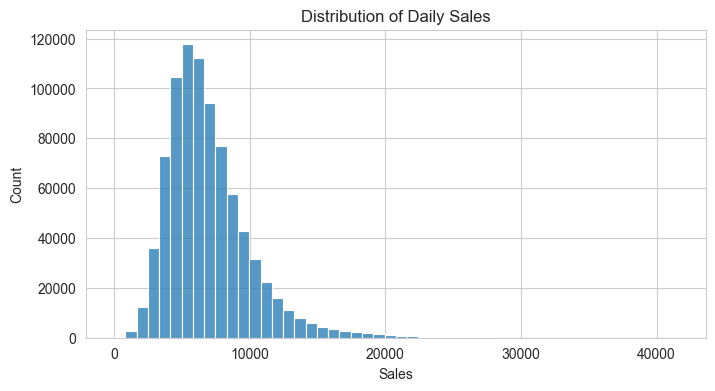

In [10]:
df["Sales"].describe()
plt.figure(figsize=(8,4))
sns.histplot(df["Sales"], bins=50)
plt.title("Distribution of Daily Sales")
plt.show()

## Save processed base dataset
Persist the cleaned and feature-enhanced dataframe to the processed folder for reuse.

In [11]:
df.to_csv("../data/processed/rossmann_base.csv", index=False)

## Reload processed data
Read the saved processed CSV with parsed dates to confirm shape and for downstream use.

In [12]:
df = load_processed()
df.shape

(844392, 22)

## Sales summary after reload
Verify sales statistics remain consistent after saving and reloading the processed dataset.

In [13]:
df["Sales"].describe()

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

## Daily sales time series
Plot total sales aggregated by date to inspect overall trends and seasonality.

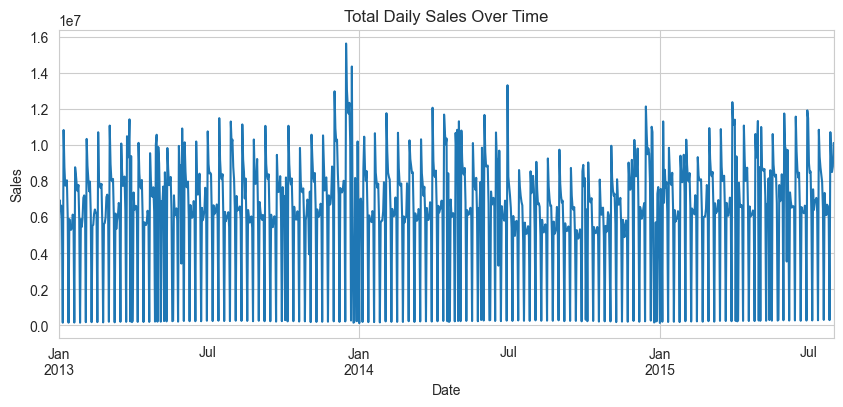

In [14]:
plt.figure(figsize=(10,4))
df.groupby("Date")["Sales"].sum().plot()
plt.title("Total Daily Sales Over Time")
plt.ylabel("Sales")
plt.show()

## Sales by weekday
Use boxplots to compare sales distributions across weekdays and spot weekly patterns.

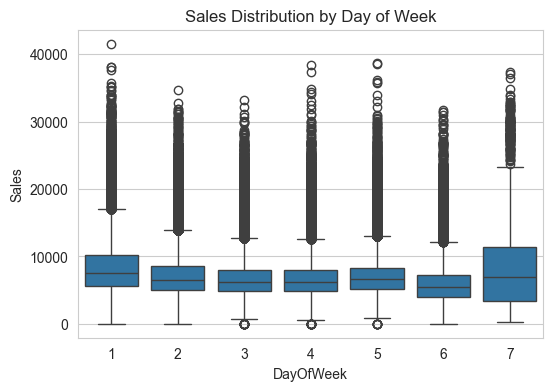

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(x="DayOfWeek", y="Sales", data=df)
plt.title("Sales Distribution by Day of Week")
plt.show()

## Sales vs promotion
Boxplot sales grouped by the promotion flag to evaluate promo lift.

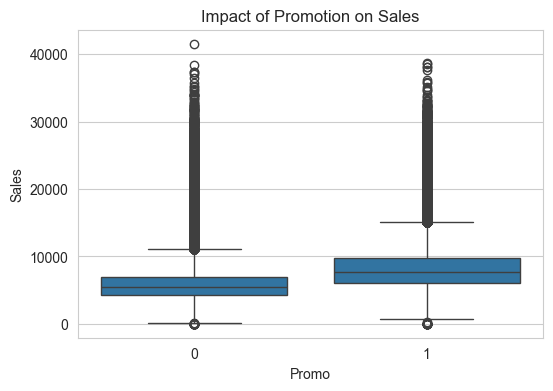

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Promo", y="Sales", data=df)
plt.title("Impact of Promotion on Sales")
plt.show()


## Sales by store type
Boxplot sales distributions across different store types to compare performance.

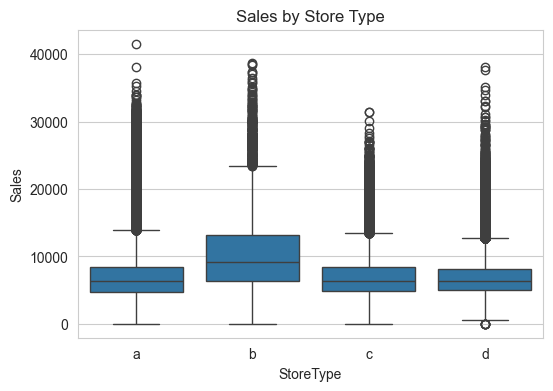

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x="StoreType", y="Sales", data=df)
plt.title("Sales by Store Type")
plt.show()

In [18]:
df = pd.read_csv("../data/processed/rossmann_base.csv", parse_dates=["Date"])

C:\Users\TestAdmin\AppData\Local\Temp\ipykernel_39560\746820774.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/rossmann_base.csv", parse_dates=["Date"])


In [19]:
drop_cols = [
    "Date",        # Used only for feature extraction
    "Customers"   # Leakage: not known before sales
]

df_model = df.drop(columns=drop_cols)

In [20]:
categorical_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_cols, numerical_cols

(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'],
 ['Store',
  'DayOfWeek',
  'Sales',
  'Open',
  'Promo',
  'SchoolHoliday',
  'CompetitionDistance',
  'CompetitionOpenSinceMonth',
  'CompetitionOpenSinceYear',
  'Promo2',
  'Promo2SinceWeek',
  'Promo2SinceYear',
  'Year',
  'Month',
  'Week',
  'Day'])

In [21]:
corr = df_model[numerical_cols].corr()["Sales"].sort_values(ascending=False)
corr

Sales                        1.000000
Promo                        0.368145
Promo2SinceWeek              0.095311
Week                         0.074472
Month                        0.073600
SchoolHoliday                0.038617
Year                         0.036169
CompetitionOpenSinceYear     0.016101
Store                        0.007710
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Day                         -0.051849
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

In [22]:
low_variance = [
    col for col in numerical_cols
    if df_model[col].nunique() < 5 and col != "Sales"
]

low_variance

['Open', 'Promo', 'SchoolHoliday', 'Promo2', 'Year']

In [23]:
selected_features = [
    "Store",
    "DayOfWeek",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "StoreType",
    "Assortment",
    "Year",
    "Month",
    "Week"
]

X = df_model[selected_features]
y = df_model["Sales"]

X.shape, y.shape

((844392, 10), (844392,))

In [24]:
from sklearn.model_selection import train_test_split

X = X.copy()
y = y.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

X_train.shape, X_test.shape

((675513, 10), (168879, 10))

In [25]:
X_train_enc = pd.get_dummies(X_train, drop_first=True)
X_test_enc = pd.get_dummies(X_test, drop_first=True)

X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

In [26]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_enc, y_train)

y_pred_lr = lr.predict(X_test_enc)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

mae, rmse, r2

NameError: name 'y_pred_lr' is not defined

In [28]:
X_train_enc.isnull().mean().sort_values(ascending=False)

CompetitionDistance    0.002562
Store                  0.000000
DayOfWeek              0.000000
Promo                  0.000000
SchoolHoliday          0.000000
Year                   0.000000
Month                  0.000000
Week                   0.000000
StoreType_b            0.000000
StoreType_c            0.000000
StoreType_d            0.000000
Assortment_b           0.000000
Assortment_c           0.000000
dtype: float64

In [29]:
from sklearn.impute import SimpleImputer

num_cols = X_train_enc.select_dtypes(include=["int64", "float64"]).columns

imputer = SimpleImputer(strategy="median")

X_train_enc[num_cols] = imputer.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols] = imputer.transform(X_test_enc[num_cols])

In [30]:
X_train_enc.isnull().sum().sum(), X_test_enc.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [32]:
lr = LinearRegression()
lr.fit(X_train_enc, y_train)

y_pred_lr = lr.predict(X_test_enc)

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

mae, rmse, r2

(1990.3565060608414, np.float64(2759.9127902156442), 0.15464374988731389)